# Importing Packages

In [3]:
import numpy as np
import cv2
import glob
import pandas as pd
import os
import matplotlib.pyplot as plt
from PIL import Image
import tensorflow as tf

# Train Data Loading

In [4]:
file_path = '/kaggle/input/aptos2019/train_1.csv'
df = pd.read_csv(file_path)

In [5]:
folder_path = '/kaggle/input/aptos2019/train_images/train_images'
image_pattern = '*.png'
image_files = glob.glob(os.path.join(folder_path, image_pattern))

# Data exploration

(2136, 3216, 3)


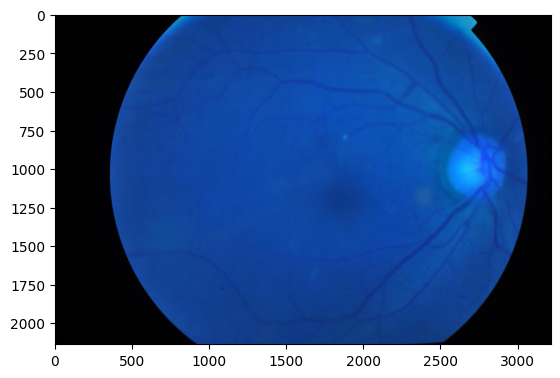

In [6]:
img = cv2.imread('/kaggle/input/aptos2019/train_images/train_images/1ae8c165fd53.png')
print(img.shape)
plt.imshow(img)

# Pre processing

In [7]:
data = []
labels = []

image_size=(128,128)
for index, row in df.iterrows():
    image_path = f"/kaggle/input/aptos2019/train_images/train_images/{row['id_code']}.png"
    image = cv2.imread(image_path)    
    image = cv2.resize(image, image_size)
    data.append(image)
    labels.append(row['diagnosis'])

# Normalization

In [8]:
X_train = np.array(data)
X_train = (X_train - np.min(X_train)) / (np.max(X_train) - np.min(X_train))
y_train = np.array(labels, dtype=np.int32)

print(X_train.shape)
print(y_train.shape)

(2930, 128, 128, 3)
(2930,)


In [9]:
print(y_train)

[2 1 4 ... 0 0 0]


# Pretrained Model loading

In [10]:
from tensorflow.keras.applications import VGG16,MobileNetV2,InceptionV3,DenseNet121,ResNet50,ResNet101

ResNet50 Model

In [11]:
base_model = ResNet50(input_shape=(128,128,3), include_top=False, weights='imagenet')
for layer in base_model.layers:
    layer.trainable = False
    
base_model.summary()

94765736/94765736 [==============================] - 0s 0us/step
Model: "resnet50"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_1 (InputLayer)        [(None, 128, 128, 3)]        0         []                            
                                                                                                  
 conv1_pad (ZeroPadding2D)   (None, 134, 134, 3)          0         ['input_1[0][0]']             
                                                                                                  
 conv1_conv (Conv2D)         (None, 64, 64, 64)           9472      ['conv1_pad[0][0]']           
                                                                                                  
 conv1_bn (BatchNormalizati  (None, 64, 64, 64)           256       ['conv1_conv[0][0]']          
 on)                      

# Adding top layer

In [12]:
from tensorflow.keras.layers import Flatten,Dense

new_model=base_model.get_layer('conv5_block3_out').output #last layer of your pretrained model
output1=Flatten()(new_model)
output=Dense(units=512,activation='relu')(output1)
output=Dense(units=5, activation='softmax')(output)

In [13]:
from tensorflow.keras.models import Model
model = Model(inputs=base_model.input, outputs=output)
model.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_1 (InputLayer)        [(None, 128, 128, 3)]        0         []                            
                                                                                                  
 conv1_pad (ZeroPadding2D)   (None, 134, 134, 3)          0         ['input_1[0][0]']             
                                                                                                  
 conv1_conv (Conv2D)         (None, 64, 64, 64)           9472      ['conv1_pad[0][0]']           
                                                                                                  
 conv1_bn (BatchNormalizati  (None, 64, 64, 64)           256       ['conv1_conv[0][0]']          
 on)                                                                                          

# Validation Data

In [14]:
val_df = pd.read_csv('/kaggle/input/aptos2019/valid.csv')

val_data = []
val_labels = []

image_size = (128,128)

for index, row in val_df.iterrows():
    image_path = f"/kaggle/input/aptos2019/val_images/val_images/{row['id_code']}.png"
    image = cv2.imread(image_path)
    image = cv2.resize(image, image_size)
    val_data.append(image)
    val_labels.append(row['diagnosis'])

In [15]:
X_val = np.array(val_data)
X_val = (X_val - np.min(X_val)) / (np.max(X_val) - np.min(X_val)).astype(np.float32)
y_val = np.array(val_labels, dtype=np.int32)

print(X_val.shape)
print(y_val.shape)

(366, 128, 128, 3)
(366,)


In [16]:
print(y_val)

[2 4 1 0 0 4 0 2 2 1 0 2 0 3 1 0 2 0 0 2 2 0 1 2 0 2 0 0 0 0 0 0 4 2 4 2 0
 0 4 0 4 2 2 4 2 1 2 4 0 3 1 2 2 2 2 0 3 0 2 1 0 2 0 0 0 0 2 2 0 0 0 1 1 0
 3 0 2 0 2 0 1 3 1 0 2 0 0 3 4 2 2 0 0 0 0 1 0 3 1 0 2 2 0 0 0 4 4 0 0 1 2
 4 0 0 2 0 0 0 0 0 3 0 2 2 0 0 4 0 0 1 0 2 0 2 2 2 1 0 0 1 0 0 0 2 0 2 1 4
 0 2 0 2 0 0 0 0 0 0 4 2 0 0 2 2 2 3 2 0 3 0 0 0 0 4 0 2 0 1 0 0 0 2 0 0 0
 0 2 0 1 3 1 0 4 0 0 2 4 0 1 0 3 0 2 2 0 1 0 3 3 1 2 0 0 2 2 0 2 0 0 2 1 0
 0 1 0 0 0 2 2 0 1 0 4 1 1 2 4 2 2 2 0 2 0 2 0 2 2 0 0 0 0 1 1 2 0 2 0 2 1
 0 0 0 2 0 2 2 2 2 0 2 2 2 0 3 2 0 0 0 0 2 2 0 2 2 0 3 0 1 2 0 4 3 0 0 0 0
 3 2 0 4 0 0 0 4 3 4 2 1 0 2 0 0 0 0 0 2 1 0 2 2 2 0 0 0 0 4 0 2 0 0 2 1 0
 0 0 0 2 2 0 2 2 3 0 3 2 1 0 2 2 1 0 0 1 4 1 0 0 2 0 2 4 4 3 0 2 0]


# Data Training

In [17]:
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [18]:
history=model.fit(X_train,y_train,validation_data=(X_val,y_val),epochs=50, batch_size=16)

Epoch 1/50


I0000 00:00:1747897491.990213      75 device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


184/184 [==============================] - 12s 33ms/step - loss: 1.1424 - accuracy: 0.6198 - val_loss: 0.9945 - val_accuracy: 0.6311
Epoch 2/50
184/184 [==============================] - 4s 20ms/step - loss: 0.9382 - accuracy: 0.6672 - val_loss: 0.9168 - val_accuracy: 0.6284
Epoch 3/50
184/184 [==============================] - 4s 20ms/step - loss: 0.9073 - accuracy: 0.6840 - val_loss: 0.8746 - val_accuracy: 0.6749
Epoch 4/50
184/184 [==============================] - 4s 20ms/step - loss: 0.8913 - accuracy: 0.6833 - val_loss: 0.8810 - val_accuracy: 0.6503
Epoch 5/50
184/184 [==============================] - 4s 19ms/step - loss: 0.8792 - accuracy: 0.6795 - val_loss: 0.8312 - val_accuracy: 0.7213
Epoch 6/50
184/184 [==============================] - 4s 19ms/step - loss: 0.8474 - accuracy: 0.6935 - val_loss: 0.8716 - val_accuracy: 0.6530
Epoch 7/50
184/184 [==============================] - 4s 19ms/step - loss: 0.8495 - accuracy: 0.6877 - val_loss: 0.8363 - val_accuracy: 0.6995
Epoch 8/5

# Test Data

In [19]:
test_df = pd.read_csv('/kaggle/input/aptos2019/test.csv')

test_data = []
test_labels = []

image_size = (128,128)

for index, row in test_df.iterrows():
    image_path = f"/kaggle/input/aptos2019/test_images/test_images/{row['id_code']}.png"
    image = cv2.imread(image_path)
    image = cv2.resize(image, image_size)
    test_data.append(image)
    test_labels.append(row['diagnosis'])
    
X_test = np.array(test_data)
X_test = (X_test - np.min(X_test)) / (np.max(X_test) - np.min(X_test)).astype(np.float32)
y_test = np.array(test_labels, dtype=np.int32)

print(X_test.shape)
print(y_test.shape)

(366, 128, 128, 3)
(366,)


# Model Evaluation

In [20]:
loss, accuracy = model.evaluate(X_test,y_test)

print(f"Test loss: {loss:.4f}")
print(f"Test accuracy: {accuracy:.4f}")

12/12 [==============================] - 1s 23ms/step - loss: 0.7214 - accuracy: 0.7377
Test loss: 0.7214
Test accuracy: 0.7377


# Reports & Confusion Matrix

In [21]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

12/12 [==============================] - 1s 21ms/step
Classification Report:
                   precision    recall  f1-score   support

           No DR       0.88      0.97      0.92       199
         Mild DR       0.40      0.60      0.48        30
     Moderate DR       0.58      0.64      0.61        87
       Severe DR       0.67      0.12      0.20        17
Proliferative DR       0.00      0.00      0.00        33

        accuracy                           0.74       366
       macro avg       0.50      0.47      0.44       366
    weighted avg       0.68      0.74      0.70       366



/opt/conda/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/opt/conda/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/opt/conda/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


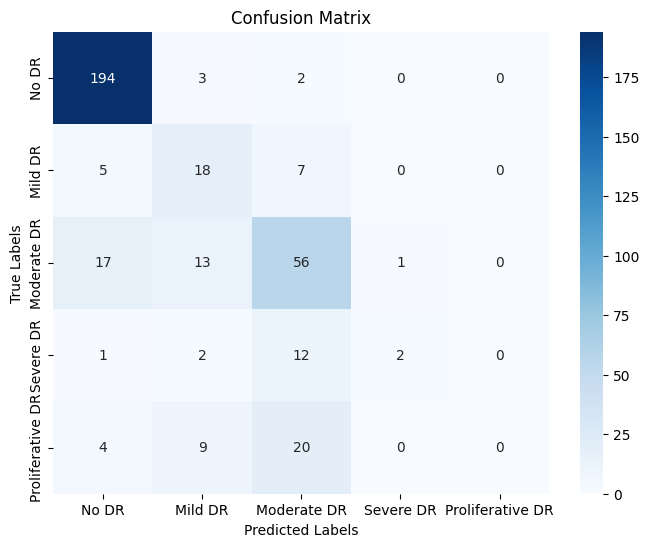

In [22]:
# Convert true labels to one-hot encoded format
y_test_oh = tf.keras.utils.to_categorical(y_test, num_classes=5)

# Get the true labels and predicted probabilities for the validation data
predictions = model.predict(X_test)
predicted_classes = np.argmax(predictions, axis=1)

# Generate the classification report
class_names = ['No DR', 'Mild DR', 'Moderate DR', 'Severe DR', 'Proliferative DR']
report = classification_report(np.argmax(y_test_oh, axis=1), predicted_classes, target_names=class_names)
print("Classification Report:\n", report)

# Generate the confusion matrix
cm = confusion_matrix(np.argmax(y_test_oh, axis=1), predicted_classes)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

In [23]:
import tensorflow.keras as keras

# Assuming you have already trained your model and have a trained model object named 'model'

# Save the model using save_model
keras.models.save_model(model, 'efficientnetb4.h5')

/tmp/ipykernel_34/2162780173.py:6: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  keras.models.save_model(model, 'efficientnetb4.h5')


# Image Number in Different Class


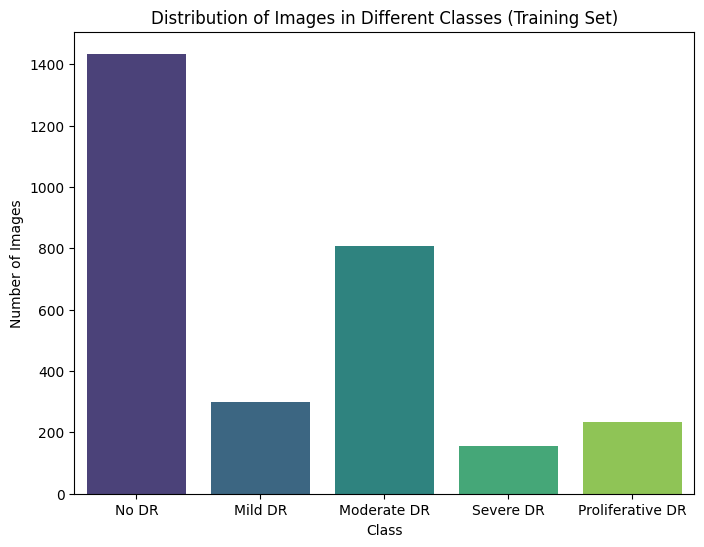

In [24]:
# train data

import seaborn as sns
import matplotlib.pyplot as plt
import tensorflow as tf

# Convert true labels to one-hot encoded format
y_train_onehot = tf.keras.utils.to_categorical(y_train, num_classes=5)

# Plot the distribution of images in different classes for the training set
plt.figure(figsize=(8, 6))
sns.countplot(x=np.argmax(y_train_onehot, axis=1), palette="viridis")
plt.xlabel('Class')
plt.ylabel('Number of Images')
plt.title('Distribution of Images in Different Classes (Training Set)')
plt.xticks(ticks=range(5), labels=['No DR', 'Mild DR', 'Moderate DR', 'Severe DR', 'Proliferative DR'])
plt.show()

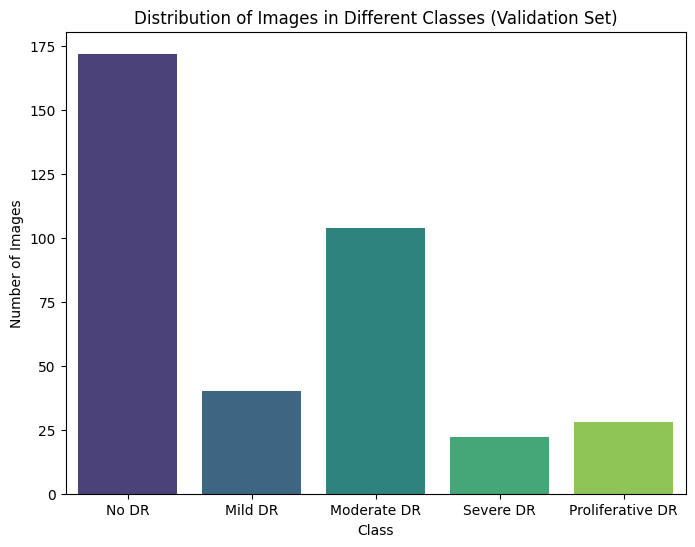

In [25]:
#val data

y_val_onehot = tf.keras.utils.to_categorical(y_val, num_classes=5)

plt.figure(figsize=(8, 6))
sns.countplot(x=np.argmax(y_val_onehot, axis=1), palette="viridis")
plt.xlabel('Class')
plt.ylabel('Number of Images')
plt.title('Distribution of Images in Different Classes (Validation Set)')
plt.xticks(ticks=range(5), labels=['No DR', 'Mild DR', 'Moderate DR', 'Severe DR', 'Proliferative DR'])
plt.show()

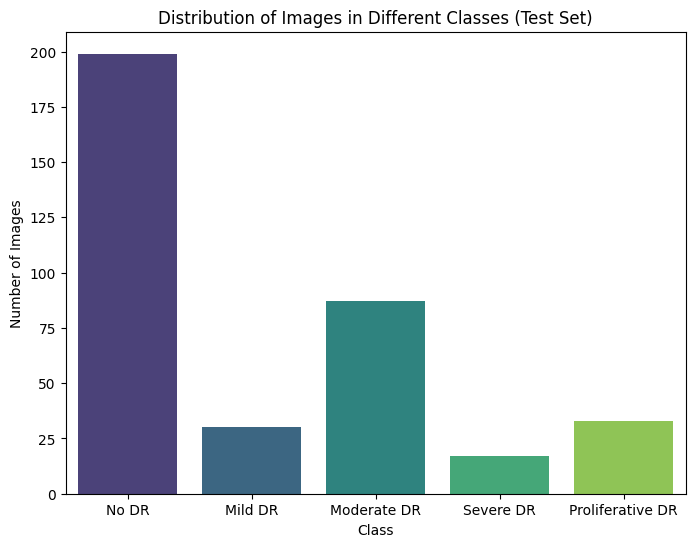

In [26]:
#test data

y_test_onehot = tf.keras.utils.to_categorical(y_test, num_classes=5)

plt.figure(figsize=(8, 6))
sns.countplot(x=np.argmax(y_test_onehot, axis=1), palette="viridis")
plt.xlabel('Class')
plt.ylabel('Number of Images')
plt.title('Distribution of Images in Different Classes (Test Set)')
plt.xticks(ticks=range(5), labels=['No DR', 'Mild DR', 'Moderate DR', 'Severe DR', 'Proliferative DR'])
plt.show()

# Implementing EfficientnetB0 Model

In [27]:
import pandas as pd
import numpy as np
import os
import cv2
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.layers import Flatten, Dense, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping

# Load the training data
train_file_path = '/kaggle/input/aptos2019/train_1.csv'
train_df = pd.read_csv(train_file_path)
train_folder_path = '/kaggle/input/aptos2019/train_images/train_images'

# Preprocess training data
train_data = []
train_labels = []
image_size = (224, 224)

for index, row in train_df.iterrows():
    image_path = os.path.join(train_folder_path, f"{row['id_code']}.png")
    image = cv2.imread(image_path)
    image = cv2.resize(image, image_size)
    train_data.append(image)
    train_labels.append(row['diagnosis'])

# Normalize and one-hot encode training data
X_train = np.array(train_data)
X_train = (X_train - np.min(X_train)) / (np.max(X_train) - np.min(X_train))
y_train = np.array(train_labels, dtype=np.int32)
X_train = np.reshape(X_train, (-1, 224, 224, 3))
y_train = to_categorical(y_train)

# Load the EfficientNetB0 model with pre-trained ImageNet weights, excluding the top (classification) layers
base_model = EfficientNetB0(input_shape=(224, 224, 3), include_top=False, weights='imagenet')

# Freeze all base model layers to prevent them from being updated during training
for layer in base_model.layers:
    layer.trainable = False

# Define additional layers for classification
new_model = base_model.output
new_model = Flatten()(new_model)
new_model = Dropout(0.2)(new_model)
new_model = Dense(512, activation='relu')(new_model)
new_model = Dropout(0.2)(new_model)
output = Dense(5, activation='softmax')(new_model)

# Create the final model by combining the base model and the new layers
model_efficientnetB0 = Model(inputs=base_model.input, outputs=output)

# Compile the model
model_efficientnetB0.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

# Define Early Stopping callback
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Train the model with fine-tuning
history_b0 = model_efficientnetB0.fit(X_train, y_train, epochs=50, batch_size=16, validation_split=0.2, callbacks=[early_stopping])

# Unfreeze some layers of the base model for fine-tuning
for layer in model_efficientnetB0.layers[-20:]:
    layer.trainable = True

# Lower the learning rate for fine-tuning
model_efficientnetB0.compile(loss='categorical_crossentropy', optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5), metrics=['accuracy'])

# Continue training the model with fine-tuning
history_fine_tuning = model_efficientnetB0.fit(X_train, y_train, epochs=50, batch_size=16, validation_split=0.2, callbacks=[early_stopping])


16705208/16705208 [==============================] - 0s 0us/step
Epoch 1/50


2025-05-22 07:13:17.725754: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:961] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inmodel_1/block2b_drop/dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


147/147 [==============================] - 17s 67ms/step - loss: 5.6983 - accuracy: 0.3997 - val_loss: 1.3562 - val_accuracy: 0.4915
Epoch 2/50
147/147 [==============================] - 5s 36ms/step - loss: 1.3685 - accuracy: 0.4872 - val_loss: 1.3010 - val_accuracy: 0.4915
Epoch 3/50
147/147 [==============================] - 5s 34ms/step - loss: 1.3714 - accuracy: 0.4842 - val_loss: 1.3469 - val_accuracy: 0.4915
Epoch 4/50
147/147 [==============================] - 5s 34ms/step - loss: 1.3540 - accuracy: 0.4889 - val_loss: 1.3091 - val_accuracy: 0.4915
Epoch 5/50
147/147 [==============================] - 5s 34ms/step - loss: 1.3492 - accuracy: 0.4889 - val_loss: 1.3121 - val_accuracy: 0.4915
Epoch 6/50
147/147 [==============================] - 5s 34ms/step - loss: 1.3509 - accuracy: 0.4889 - val_loss: 1.3371 - val_accuracy: 0.4915
Epoch 7/50
147/147 [==============================] - 5s 37ms/step - loss: 1.3361 - accuracy: 0.4889 - val_loss: 1.3150 - val_accuracy: 0.4915
Epoch 1/5

In [28]:
# Test Data
test_df = pd.read_csv('/kaggle/input/aptos2019/test.csv')

test_data = []
test_labels = []

image_size = (224,224)

for index, row in test_df.iterrows():
    image_path = f"/kaggle/input/aptos2019/test_images/test_images/{row['id_code']}.png"
    image = cv2.imread(image_path)
    image = cv2.resize(image, image_size)
    test_data.append(image)
    test_labels.append(row['diagnosis'])
    
X_test = np.array(test_data)
X_test = (X_test - np.min(X_test)) / (np.max(X_test) - np.min(X_test)).astype(np.float32)
X_test = np.reshape(X_test, (-1, 224, 224, 3))
y_test = np.array(test_labels, dtype=np.int32)
y_test = to_categorical(y_test)

# Model Evaluation
loss, accuracy = model_efficientnetB0.evaluate(X_test,y_test)

print(f"Test loss: {loss:.4f}")
print(f"Test accuracy: {accuracy:.4f}")

12/12 [==============================] - 2s 117ms/step - loss: 1.2428 - accuracy: 0.5437
Test loss: 1.2428
Test accuracy: 0.5437


# Implementing ResNet152V2 Model

In [29]:
import pandas as pd
import numpy as np
import os
import cv2
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.applications import ResNet152V2
from tensorflow.keras.layers import Flatten, Dense, Dropout
from tensorflow.keras.models import Model

# Load the training data
train_file_path = '/kaggle/input/aptos2019/train_1.csv'
train_df = pd.read_csv(train_file_path)
train_folder_path = '/kaggle/input/aptos2019/train_images/train_images'

# Preprocess training data
train_data = []
train_labels = []
image_size = (380, 380)

for index, row in train_df.iterrows():
    image_path = os.path.join(train_folder_path, f"{row['id_code']}.png")
    image = cv2.imread(image_path)
    image = cv2.resize(image, image_size)
    train_data.append(image)
    train_labels.append(row['diagnosis'])

# Normalize and one-hot encode training data
X_train = np.array(train_data)
X_train = X_train.astype('float32') / 255.0  # Normalize pixel values to [0, 1]
y_train = np.array(train_labels, dtype=np.int32)
y_train = to_categorical(y_train)

# Load the validation data
val_file_path = '/kaggle/input/aptos2019/valid.csv'
val_df = pd.read_csv(val_file_path)
val_folder_path = '/kaggle/input/aptos2019/val_images/val_images'

# Preprocess validation data
val_data = []
val_labels = []
for index, row in val_df.iterrows():
    image_path = os.path.join(val_folder_path, f"{row['id_code']}.png")
    image = cv2.imread(image_path)
    image = cv2.resize(image, image_size)
    val_data.append(image)
    val_labels.append(row['diagnosis'])

# Normalize and one-hot encode validation data
X_val = np.array(val_data)
X_val = X_val.astype('float32') / 255.0  # Normalize pixel values to [0, 1]
y_val = np.array(val_labels, dtype=np.int32)
y_val = to_categorical(y_val)

# Load the ResNet152V2 model with pre-trained ImageNet weights
base_model = ResNet152V2(input_shape=(380, 380, 3), include_top=False, weights='imagenet')

# Freeze all base model layers to prevent them from being updated during training
for layer in base_model.layers:
    layer.trainable = False

# Define additional layers for classification
new_model = base_model.output
new_model = Flatten()(new_model)
new_model = Dropout(0.5)(new_model)
new_model = Dense(512, activation='relu')(new_model)
new_model = Dropout(0.5)(new_model)
output = Dense(5, activation='softmax')(new_model)

# Create the final model by combining the base model and the new layers
model_ResNet152V2 = Model(inputs=base_model.input, outputs=output)

# Compile the model
model_ResNet152V2.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

# Train the model
history_ResNet152V2 = model_ResNet152V2.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=50, batch_size=16)


234545216/234545216 [==============================] - 1s 0us/step
Epoch 1/50
184/184 [==============================] - 57s 254ms/step - loss: 8.6806 - accuracy: 0.6444 - val_loss: 0.7889 - val_accuracy: 0.7350
Epoch 2/50
184/184 [==============================] - 40s 216ms/step - loss: 1.0105 - accuracy: 0.7334 - val_loss: 0.7406 - val_accuracy: 0.7623
Epoch 3/50
184/184 [==============================] - 40s 217ms/step - loss: 0.8931 - accuracy: 0.7352 - val_loss: 0.7362 - val_accuracy: 0.7623
Epoch 4/50
184/184 [==============================] - 40s 217ms/step - loss: 0.8271 - accuracy: 0.7444 - val_loss: 0.7042 - val_accuracy: 0.7623
Epoch 5/50
184/184 [==============================] - 40s 216ms/step - loss: 0.7063 - accuracy: 0.7587 - val_loss: 0.6603 - val_accuracy: 0.7486
Epoch 6/50
184/184 [==============================] - 40s 215ms/step - loss: 0.7147 - accuracy: 0.7618 - val_loss: 0.6968 - val_accuracy: 0.7787
Epoch 7/50
184/184 [==============================] - 40s 215ms

In [30]:
# Test Data
test_df = pd.read_csv('/kaggle/input/aptos2019/test.csv')

test_data = []
test_labels = []

image_size = (380, 380)  # Adjusted to match the input size for ResNeXt50

for index, row in test_df.iterrows():
    image_path = f"/kaggle/input/aptos2019/test_images/test_images/{row['id_code']}.png"
    image = cv2.imread(image_path)
    image = cv2.resize(image, image_size)
    test_data.append(image)
    test_labels.append(row['diagnosis'])
    
X_test = np.array(test_data)
X_test = X_test.astype('float32') / 255.0  # Normalize pixel values to [0, 1] for ResNeXt50
X_test = np.reshape(X_test, (-1, 380, 380, 3))
y_test = np.array(test_labels, dtype=np.int32)
y_test = to_categorical(y_test)

# Model Evaluation
loss, accuracy = model_ResNet152V2.evaluate(X_test, y_test)

print(f"Test loss: {loss:.4f}")
print(f"Test accuracy: {accuracy:.4f}")


12/12 [==============================] - 7s 318ms/step - loss: 1.0856 - accuracy: 0.8060
Test loss: 1.0856
Test accuracy: 0.8060


In [31]:
import tensorflow.keras as keras

# Assuming you have already trained your model and have a trained model object named 'model'

# Save the model using save_model
keras.models.save_model(model_ResNet152V2, 'ResNet152V2.h5')

/tmp/ipykernel_34/541313345.py:6: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  keras.models.save_model(model_ResNet152V2, 'ResNet152V2.h5')


In [32]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

12/12 [==============================] - 6s 330ms/step


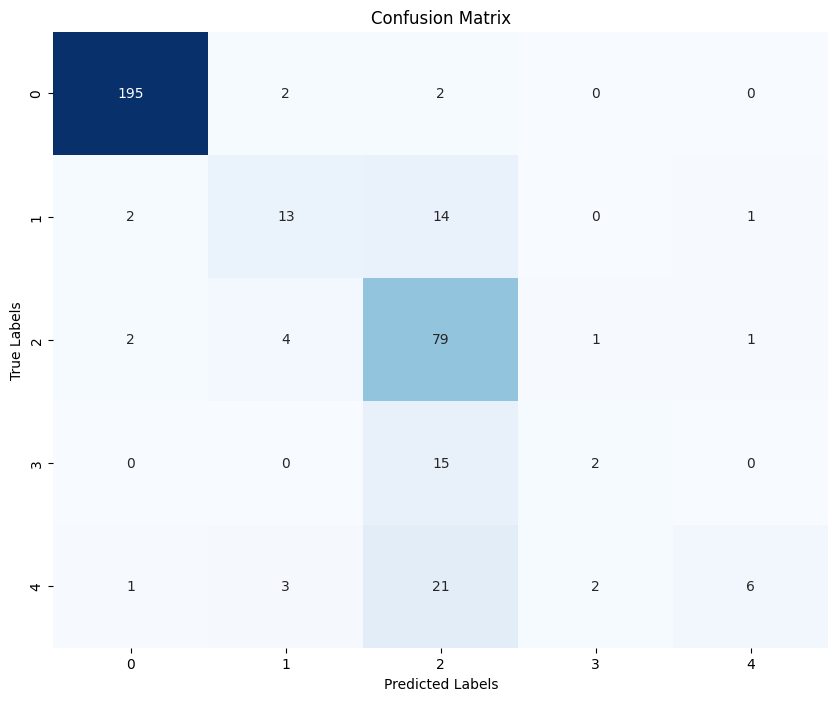

In [33]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Predict labels for the test set
y_pred = model_ResNet152V2.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

# Compute confusion matrix
conf_matrix = confusion_matrix(y_true, y_pred_classes)

# Plot confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.xticks(ticks=np.arange(5) + 0.5, labels=[0, 1, 2, 3, 4])
plt.yticks(ticks=np.arange(5) + 0.5, labels=[0, 1, 2, 3, 4])
plt.show()


# Efficientnet B5 

In [35]:
!pip install efficientnet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.7/50.7 kB 1.8 MB/s eta 0:00:00


In [37]:
import pandas as pd
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.utils import class_weight
from keras.callbacks import LearningRateScheduler
import numpy as np
from keras.layers import Flatten, Dropout, Dense
from keras.models import Model
from efficientnet.tfkeras import EfficientNetB5  # Change import
import tensorflow as tf  # Import TensorFlow
from tensorflow.keras.activations import softmax  # Import softmax activation function

In [38]:
# Load data
train = pd.read_csv('/kaggle/input/aptos2019/train_1.csv')
test = pd.read_csv('/kaggle/input/aptos2019/test.csv')
valid=pd.read_csv('/kaggle/input/aptos2019/valid.csv')

# Preprocess data
train["id_code"] = train["id_code"].apply(lambda x: x + ".png")
test["id_code"] = test["id_code"].apply(lambda x: x + ".png")
valid["id_code"] = valid["id_code"].apply(lambda x: x + ".png")
train['diagnosis'] = train['diagnosis'].astype('str')
test['diagnosis'] = test['diagnosis'].astype('str')
valid['diagnosis'] = valid['diagnosis'].astype('str')

# Define model parameters
BATCH_SIZE = 8
HEIGHT = 380
WIDTH = 380

# Create data generators
train_datagen=ImageDataGenerator(rescale=1./255)
train_generator=train_datagen.flow_from_dataframe(
    dataframe=train,
    directory="/kaggle/input/aptos2019/train_images/train_images",
    x_col="id_code",
    y_col="diagnosis",
    class_mode="categorical",
    batch_size=BATCH_SIZE,
    target_size=(HEIGHT, WIDTH),
    seed=0)

validation_datagen = ImageDataGenerator(rescale=1./255)
valid_generator=validation_datagen.flow_from_dataframe(
    dataframe=valid,
    directory="/kaggle/input/aptos2019/val_images/val_images",
    x_col="id_code",
    y_col="diagnosis",
    class_mode="categorical", 
    batch_size=BATCH_SIZE,   
    target_size=(HEIGHT, WIDTH),
    seed=0)

test_datagen = ImageDataGenerator(rescale=1./255)
test_generator = test_datagen.flow_from_dataframe(  
        dataframe=test,
        directory="/kaggle/input/aptos2019/test_images/test_images",
        x_col="id_code",
        y_col="diagnosis",  # Include y_col to get labels for evaluation
        batch_size=BATCH_SIZE,
        class_mode="categorical",  # Set class_mode to 'categorical'
        shuffle=False,
        target_size=(HEIGHT, WIDTH),
        seed=0)

Found 2930 validated image filenames belonging to 5 classes.
Found 366 validated image filenames belonging to 5 classes.
Found 366 validated image filenames belonging to 5 classes.


In [39]:
# Load the EfficientNetB5 model with pre-trained ImageNet weights
base_model = EfficientNetB5(input_shape=(HEIGHT, WIDTH, 3), include_top=False, weights='imagenet')

# Freeze all base model layers to prevent them from being updated during training
for layer in base_model.layers:
    layer.trainable = False

# Define additional layers for classification
x = base_model.output
x = Flatten()(x)
x = Dropout(0.2)(x)
x = Dense(512, activation='relu')(x)
x = Dropout(0.2)(x)
output = Dense(5, activation=softmax)(x)  # Use softmax activation for multi-class classification

# Create the final model by combining the base model and the new layers
model_efficientnetB5 = Model(inputs=base_model.input, outputs=output)

# Compile the model
model_efficientnetB5.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

# Define a learning rate schedule
def lr_schedule(epoch):
    lr = 0.001
    if epoch > 10:
        lr *= 0.5e-3
    elif epoch > 7:
        lr *= 1e-3
    elif epoch > 5:
        lr *= 1e-2
    elif epoch > 3:
        lr *= 1e-1
    print('Learning rate: ', lr)
    return lr

lr_scheduler = LearningRateScheduler(lr_schedule)

history_b5 = model_efficientnetB5.fit(
    train_generator,
    epochs=7,
    validation_data=valid_generator,
    callbacks=[lr_scheduler])  # use learning rate scheduler

115515256/115515256 [==============================] - 1s 0us/step
Learning rate:  0.001
Epoch 1/7


2025-05-22 08:00:19.220369: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:961] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inmodel_3/block1b_drop/dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


367/367 [==============================] - 364s 957ms/step - loss: 10.8330 - accuracy: 0.6403 - val_loss: 0.8721 - val_accuracy: 0.6831 - lr: 0.0010
Learning rate:  0.001
Epoch 2/7
367/367 [==============================] - 323s 879ms/step - loss: 0.9376 - accuracy: 0.6850 - val_loss: 0.7894 - val_accuracy: 0.7432 - lr: 0.0010
Learning rate:  0.001
Epoch 3/7
367/367 [==============================] - 320s 873ms/step - loss: 0.8956 - accuracy: 0.6949 - val_loss: 0.7878 - val_accuracy: 0.7077 - lr: 0.0010
Learning rate:  0.001
Epoch 4/7
367/367 [==============================] - 319s 870ms/step - loss: 0.8530 - accuracy: 0.7003 - val_loss: 0.7142 - val_accuracy: 0.7295 - lr: 0.0010
Learning rate:  0.0001
Epoch 5/7
367/367 [==============================] - 321s 873ms/step - loss: 0.7613 - accuracy: 0.7130 - val_loss: 0.6848 - val_accuracy: 0.7350 - lr: 1.0000e-04
Learning rate:  0.0001
Epoch 6/7
367/367 [==============================] - 320s 872ms/step - loss: 0.7630 - accuracy: 0.7198 

In [40]:
# Evaluate the model on test data
loss, accuracy = model_efficientnetB5.evaluate(test_generator, verbose=1)
print(f"Test loss: {loss:.4f}")
print(f"Test accuracy: {accuracy:.4f}")

46/46 [==============================] - 34s 745ms/step - loss: 0.6443 - accuracy: 0.7650
Test loss: 0.6443
Test accuracy: 0.7650


In [ ]:
import tensorflow.keras as keras

# Assuming you have already trained your model and have a trained model object named 'model'

# Save the model using save_model
keras.models.save_model(model_efficientnetB5, 'efficientnetb5.h5')